# Pandas: Datetimes, Custom Apply, Iterrows, and Merges

In [1]:
import pandas as pd
import numpy as np

## Merges & Joins

|  | Merges | Joins |
| --- | --- | --- |
| **Definition:** | Merging combines two or more DataFrames into a single DataFrame based on one or more common columns or indexes. | Joining is a specific type of merge operation that combines two DataFrames based on their indexes. |
| **Focus:** | Merging is often used when you have datasets with different pieces of information that you want to combine based on some shared key. | Joining is especially useful when you have DataFrames with matching index values, and you want to combine them based on these index values. |
| **Types of Joins:** |  inner, outer, left, and right  | inner, outer, left, and right  |
| **Syntax:** |  merge(): The merge() function is a standalone function and is not tied to any specific DataFrame. It takes two DataFrames as arguments and allows you to specify the columns to join on using the on parameter.  | join(): The join() method is called on one DataFrame and takes another DataFrame as an argument. It joins the two DataFrames on their indexes.  |


### Merges

In [31]:
# Sample DataFrames for merge
df1 = pd.DataFrame({'key': ['A', 'B', 'C', 'D'],
                    'value1': [1, 2, 3, 4]})

df2 = pd.DataFrame({'key': ['B', 'D', 'E', 'F'],
                    'value2': [5, 6, 7, 8]})


# Sample DataFrames for joins
df3 = pd.DataFrame({'key': ['A', 'B', 'C', 'D'],
                    'value1': [1, 2, 3, 4]}, index=[0, 1, 2, 3])

df4 = pd.DataFrame({'key': ['Position 0', 'Position 1', 'Position 2', 'Position 3', 'Position 4'],
                    'value2': [5, 6, 7, 8, 9]}, index=[0, 2, 1, 3, 4])
                    # notice the out of order index above ^


#### inner join

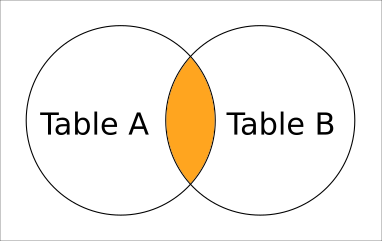

In [3]:
merged_inner = pd.merge(df1, df2, on='key')
display(merged_inner)

,key,value1,value2
0,B,2,5
1,D,4,6


In [32]:
result_inner = df3.join(df4, lsuffix='_l', rsuffix='_r')
display(result_inner)

,key_l,value1,key_r,value2
0,A,1,Position 0,5
1,B,2,Position 2,7
2,C,3,Position 1,6
3,D,4,Position 3,8


#### Outer Merge(full outer join)

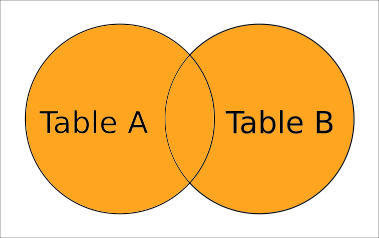

In [5]:
merged_outer = pd.merge(df1, df2, on='key', how='outer')
display(merged_outer)

,key,value1,value2
0,A,1.0,NaN
1,B,2.0,5.0
2,C,3.0,NaN
3,D,4.0,6.0
4,E,NaN,7.0
5,F,NaN,8.0


In [33]:
result_outer = df3.join(df4, how='outer', lsuffix='_l', rsuffix='_r')
display(result_outer)

,key_l,value1,key_r,value2
0,A,1.0,Position 0,5
1,B,2.0,Position 2,7
2,C,3.0,Position 1,6
3,D,4.0,Position 3,8
4,NaN,NaN,Position 4,9


In [27]:
# Sample DataFrames for merge
df1 = pd.DataFrame({'key': ['A', 'B', 'C', 'D'],
                    'value1': [1, 2, 3, 4]})

df2 = pd.DataFrame({'key': ['B', 'D', 'E', 'F'],
                    'value2': [5, 6, 7, 8]})


# Sample DataFrames for joins
df3 = pd.DataFrame({'key': ['A', 'B', 'C', 'D'],
                    'value1': [1, 2, 3, 4]}, index=[0, 1, 2, 3])

df4 = pd.DataFrame({'key': ['Position 0', 'Position 1', 'Position 2', 'Position 3', 'Position 4'],
                    'value2': [5, 6, 7, 8, 9]}, index=[0, 2, 1, 3, 4])


#### Left Merge(left outer join)

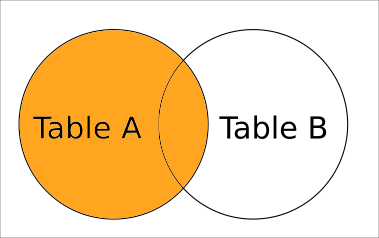

In [8]:
merged_left = pd.merge(df1, df2, on='key', how='left')
display(merged_left)

,key,value1,value2
0,A,1,NaN
1,B,2,5.0
2,C,3,NaN
3,D,4,6.0


In [28]:
result_left = df3.join(df4, how='left', lsuffix='_l', rsuffix='_r')
display(result_left)

,key_l,value1,key_r,value2
0,A,1,Position 0,5
1,B,2,Position 2,7
2,C,3,Position 1,6
3,D,4,Position 3,8


#### Right Merge(right outer join)

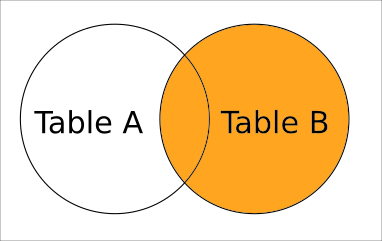

In [30]:
merged_right = pd.merge(df1, df2, on='key', how='right')
display(merged_right)

,key,value1,value2
0,B,2.0,5
1,D,4.0,6
2,E,NaN,7
3,F,NaN,8


In [29]:
result_right = df3.join(df4, how='right', lsuffix='_l', rsuffix='_r')
display(result_right)

,key_l,value1,key_r,value2
0,A,1.0,Position 0,5
2,C,3.0,Position 1,6
1,B,2.0,Position 2,7
3,D,4.0,Position 3,8
4,NaN,NaN,Position 4,9


In summary, the choice between `.merge()` and `.join()` depends on your specific use case and the complexity of your data merging needs. If you have simple index-based join operations, `.join()` may be a good choice. On the other hand, if you need more control and flexibility for merging DataFrames, especially when dealing with non-index columns or complex join scenarios, `.merge()` is the better option.

## Iterrows

Iterrows allows you to iterate over the rows of a DataFrame, providing access to each row's data as a series or dictionary. iterrows() is useful when you need to apply custom operations to each row of your dataset or extract information row by row. But it performs poorly on large DataFrames because it involves creating a Series for each row, which can be memory-intensive and lead to slower execution times.

In [44]:
data = {'Name': ['Alice', 'Bob', 'Charlie', 'David'],
        'Age': [25, 30, 35, 28],
        'City': ['New York', 'Los Angeles', 'Chicago', 'Houston']}

df = pd.DataFrame(data)
df_copy = df.copy()
display(df)

,Name,Age,City
0,Alice,25,New York
1,Bob,30,Los Angeles
2,Charlie,35,Chicago
3,David,28,Houston


In [39]:
# Iterating through the DataFrame
df2 = df_copy

for index, row in df2.iterrows():
    print(row)
    print(type(row))
    print('-----------')
    name = row['Name']
    age = row['Age']
    city = row['City']
    
    # Perform some operation on each row (e.g., print information)
    print(f"Index: {index}, Name: {name}, Age: {age}, City: {city}")
    print('--------------------------------------------------------')


Name       Alice
Age           25
City    NEW YORK
Name: 0, dtype: object
<class 'pandas.core.series.Series'>
-----------
Index: 0, Name: Alice, Age: 25, City: NEW YORK
--------------------------------------------------------
Name            Bob
Age              30
City    LOS ANGELES
Name: 1, dtype: object
<class 'pandas.core.series.Series'>
-----------
Index: 1, Name: Bob, Age: 30, City: LOS ANGELES
--------------------------------------------------------
Name    Charlie
Age          35
City    CHICAGO
Name: 2, dtype: object
<class 'pandas.core.series.Series'>
-----------
Index: 2, Name: Charlie, Age: 35, City: CHICAGO
--------------------------------------------------------
Name      David
Age          28
City    HOUSTON
Name: 3, dtype: object
<class 'pandas.core.series.Series'>
-----------
Index: 3, Name: David, Age: 28, City: HOUSTON
--------------------------------------------------------


In [43]:
# Custom Aggregations

data = {'Name': ['Alice', 'Bob', 'Charlie', 'David'],
        'Age': [25, 30, 35, 28],
        'City': ['New York', 'Los Angeles', 'Chicago', 'Houston'],
        'Total_Score': [1, 2, 3, 4],
        'Example': [100, 2000, 300, 4000]}

df = pd.DataFrame(data)

for index, row in df.iterrows():
    total_score = row['Age'] + row['Example']
    df.loc[index, 'Total_Score'] = total_score
display(df)

# This is a very long form way of making another col based on using an custom aggregation
# on existing cols. A better way is the apply function which we will touch on later

,Name,Age,City,Total_Score,Example
0,Alice,25,New York,125,100
1,Bob,30,Los Angeles,2030,2000
2,Charlie,35,Chicago,335,300
3,David,28,Houston,4028,4000


In [46]:
# Row Selection and Filtering
df4 = df_copy
selected_rows = []
for index, row in df4.iterrows():
    if row['Age'] < 30:
        selected_rows.append(row)
selected_df = pd.DataFrame(selected_rows)
display(selected_df)

# Conditional filtering (boolean masking will work better here)
print('Using Filtering by Boolean Mask: ')
bool_masking_ver = df4[df4['Age'] < 30]
display(bool_masking_ver)

,Name,Age,City
0,Alice,25,New York
3,David,28,Houston


Using Filtering by Boolean Mask: 


,Name,Age,City
0,Alice,25,New York
3,David,28,Houston


In [16]:
# Generating New Features
data = {'Name': ['Alice', 'Bob', 'Charlie', 'David'],
        'Age': [25, 30, 35, 28],
        'City': ['New York', 'Los Angeles', 'Chicago', 'Houston'],
        'Total_Score': [1, 2, 3, 4],
        'Example': [100, 2000, 300, 4000]}

df = pd.DataFrame(data)
# df_copy = df.copy()
for index, row in df.iterrows():
    df.at[index, 'Age_Category'] = 'Young' if row['Age'] < 30 else 'Old'
display(df)
# Again apply will work better here

,Name,Age,City,Total_Score,Example,Age_Category
0,Alice,25,New York,1,100,Young
1,Bob,30,Los Angeles,2,2000,Old
2,Charlie,35,Chicago,3,300,Old
3,David,28,Houston,4,4000,Young


In [47]:
# Case 5: Text Processing (Example: Uppercase City Names)
df6 = df_copy
for index, row in df6.iterrows():
    city = row['City']
    df6.loc[index, 'City'] = city.upper()
display(df6)

# df6['City'] = df6['City'].str.upper() # would do the same

,Name,Age,City
0,Alice,25,NEW YORK
1,Bob,30,LOS ANGELES
2,Charlie,35,CHICAGO
3,David,28,HOUSTON


## Apply

The apply method is a versatile and essential tool within its toolkit. It allows you to apply a function to each element (cell) along one or more axes of a DataFrame, which enables you to perform custom operations and transformations on your data.

In [52]:
import pandas as pd

data = {'A': [1, 2, 3, 4],
        'B': [5, 6, 7, 8],
        'C': [9, 10, 11, 12],
        'D': ['t', 'e', 's', 't']}
df = pd.DataFrame(data)

In [53]:
# Define a function to double the values
def double(x):
    return x.sum()

# Apply the function to each column
result = df.apply(double, axis=0)
print(result)

A      10
B      26
C      42
D    test
dtype: object


In [50]:
# Define a function to square the values
def square(x):
    return x ** 2

# Apply the function to columns 'A' and 'B'
df[['A', 'B']] = df[['A', 'B']].apply(square)
print(df)

    A   B   C  D
0   1  25   9  t
1   4  36  10  e
2   9  49  11  s
3  16  64  12  t


In [54]:
# Use a lambda function to add 10 to column 'C'
df['C'] = df['C'].apply(lambda x: x + 10)
print(df)

   A  B   C  D
0  1  5  19  t
1  2  6  20  e
2  3  7  21  s
3  4  8  22  t


#### apply on rows (axis=1)

In [22]:
data = {'A': [1, 2, 3, 4],
        'B': [5, 6, 7, 8],
        'C': [9, 10, 11, 12],
        'D': ['t', 'e', 's', 't']}
df = pd.DataFrame(data)

# Example 1: Calculate the sum of columns 'A', 'B', and 'C' for each row
df['Sum ABC'] = df.apply(lambda row: row['A'] + row['B'] + row['C'], axis=1)

# Example 2: Convert values in column 'D' to uppercase for each row
df['D Uppercase'] = df.apply(lambda row: row['D'].upper(), axis=1)

# Example 3: Concatenate values in columns 'A' and 'B' for each row
df['A and B'] = df.apply(lambda row: str(row['A']) + ' and ' + str(row['B']), axis=1)

# Display the DataFrame
print(df)

   A  B   C  D  Sum ABC D Uppercase  A and B
0  1  5   9  t       15           T  1 and 5
1  2  6  10  e       18           E  2 and 6
2  3  7  11  s       21           S  3 and 7
3  4  8  12  t       24           T  4 and 8


#### Differences between row and cols with apply

In [23]:
data = {'A': [1, 2, 3],
        'B': [4, 5, 6],
        'C': [7, 8, 9]}

df = pd.DataFrame(data)
display(df)
# Example with axis=0 (Column-Wise)
column_sum = df.apply(lambda column: column.sum(), axis=0)
# print("Column Sum:")
display(column_sum)

# Example with axis=1 (Row-Wise)
row_sum = df.apply(lambda row: row.sum(), axis=1)
print("\nRow Product:")
display(row_sum)

,A,B,C
0,1,4,7
1,2,5,8
2,3,6,9


A     6
B    15
C    24
dtype: int64


Row Product:


0    12
1    15
2    18
dtype: int64

#### Advanced examples

In [59]:
data = {
    'Student': ['Alice', 'Bob', 'Charlie', 'David'],
    'Math': [95, 52, 88, 89],
    'Science': [90, 68, 85, 76],
    'History': [88, 61, 70, 62]
}

df = pd.DataFrame(data)
display(df)
copy_df = df.copy()

,Student,Math,Science,History
0,Alice,95,90,88
1,Bob,52,68,61
2,Charlie,88,85,70
3,David,89,76,62


In [61]:
def calculate_grade(score):
    return 'A' if score >= 90 else 'B' if score >= 80 else 'C' if score >= 70 else 'D'

df['Math Grade'] = df['Math'].apply(calculate_grade)
df['Science Grade'] = df['Science'].apply(calculate_grade)
df['History Grade'] = df['History'].apply(calculate_grade)
print(df)

   Student  Math  Science  History Math Grade Science Grade History Grade
0    Alice    95       90       88          A             A             B
1      Bob    52       68       61          D             D             D
2  Charlie    88       85       70          B             B             C
3    David    89       76       62          B             C             D


In [ ]:
df2 = copy_df
df2[['Math Grade', 'Science Grade', 'History Grade']] = df2[['Math', 'Science', 'History']].applymap(calculate_grade)
display(df2)

,Student,Math,Science,History,Math Grade,Science Grade,History Grade
0,Alice,95,90,88,A,A,B
1,Bob,52,68,61,D,D,D
2,Charlie,88,85,70,B,B,C
3,David,89,76,62,B,C,D


In [63]:
data = {
    'Student': ['Alice', 'Bob', 'Charlie', 'David'],
    'Math': [95, 52, 88, 89],
    'Science': [90, 68, 85, 76],
    'History': [88, 61, 70, 62]
}

df = pd.DataFrame(data)

def calculate_grade(row):
    #average_score = (row['Math'] + row['Science'] + row['History']) / 3
    average_score = row[['Math', 'Science', 'History']].mean()
    return 'A' if average_score >= 90 else 'B' if average_score >= 80 else 'C' if average_score >= 70 else 'D'

df['Average Grade'] = df.apply(calculate_grade, axis=1)
display(df)

,Student,Math,Science,History,Average Grade
0,Alice,95,90,88,A
1,Bob,52,68,61,D
2,Charlie,88,85,70,B
3,David,89,76,62,C


## Datetimes

Pandas datetime functionality provides powerful tools for working with date and time data in Python. It is an essential part of data analysis and manipulation when dealing with time series data, event timestamps, and various temporal data-related tasks.

In [72]:
# Creating a single datetime object
date = pd.to_datetime('2023-09-21')
print(date)
print(type(date))

test = {'date': [date]}
df = pd.DataFrame(test)
print(type(df))
display(df)


2023-09-21 00:00:00
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas.core.frame.DataFrame'>


,date
0,2023-09-21


In [ ]:
# Parsing datetime strings into datetime objects
date_str = '2023-09-22 14:30:00'
parsed_date = pd.to_datetime(date_str)
print(parsed_date)

2023-09-22 14:30:00


In [ ]:
# Creating a DataFrame with datetime strings
data = {'Date': ['2023-09-21', '2023-09-22', '2023-09-23'],
        'Value': [10, 20, 15]}
df = pd.DataFrame(data)

# Converting 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])
display(df)
print(df.dtypes)

,Date,Value
0,2023-09-21,10
1,2023-09-22,20
2,2023-09-23,15


Date     datetime64[ns]
Value             int64
dtype: object


#### The .dt accessor

The .dt accessor in Pandas is used to access various datetime properties and methods associated with datetime objects within a Pandas Series or DataFrame. It provides a convenient way to work with date and time components. 

In [ ]:
# Create a DataFrame with datetime values
data = {'Date1': ['2023-09-21 14:30:00', '2023-09-22 10:45:00'],
        'Date2': ['2022-08-15 08:00:00', '2024-03-10 16:20:00']}
df = pd.DataFrame(data)

# Convert the 'Date1' and 'Date2' columns to datetime objects
df['Date1'] = pd.to_datetime(df['Date1'])
df['Date2'] = pd.to_datetime(df['Date2'])

# Calculate the differences between the datetime values
df['Year_Diff'] = (df['Date2'].dt.year - df['Date1'].dt.year)
df['Month_Diff'] = (df['Date2'].dt.month - df['Date1'].dt.month)
df['Day_Diff'] = (df['Date2'].dt.day - df['Date1'].dt.day)
df['Hour_Diff'] = (df['Date2'].dt.hour - df['Date1'].dt.hour)
df['Minute_Diff'] = (df['Date2'].dt.minute - df['Date1'].dt.minute)

# Display the DataFrame with differences
display(df)


,Date1,Date2,Year_Diff,Month_Diff,Day_Diff,Hour_Diff,Minute_Diff
0,2023-09-21 14:30:00,2022-08-15 08:00:00,-1,-1,-6,-6,-30
1,2023-09-22 10:45:00,2024-03-10 16:20:00,1,-6,-12,6,-25


#### Datetime & custom format

If strings are in these formats the .to_datetime() an parse them out.

- ISO 8601 Format: This is the international standard for representing dates and times. Examples include '2023-09-21' for a date and '2023-09-21T14:30:00' for a date and time.

- Common Date Formats: Many date formats like 'mm/dd/yyyy', 'dd/mm/yyyy', and 'yyyy-mm-dd' are recognized without specifying a custom format.

- Common Time Formats: Standard time formats like 'HH:MM:SS' or 'HH:MM:SS.mmmmmm' are typically recognized without a custom format.

- Date-Time Separators: Pandas can often handle variations in date-time separators, such as '/', '-', or 'T', without specifying a custom format.


If not a custom format is needed using directives from https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior 

In [ ]:
# Standard ISO 8601 date and time format
iso_date = pd.to_datetime('2023-09-21T14:30:00')
# iso_date.
# Common date format (no custom format needed)
common_date = pd.to_datetime('09/21/2023')

# Common time format (no custom format needed)
common_time = pd.to_datetime('14:30:00')

print("ISO Date:", iso_date)
print("Common Date:", common_date)
print("Common Time:", common_time)

ISO Date: 2023-09-21 14:30:00
Common Date: 2023-09-21 00:00:00
Common Time: 2023-09-21 14:30:00


In [ ]:
# Sample date string with a custom format
date_str = '2023-09-21 14:30:00'

# Parse the date string with the custom format
custom_format_date = pd.to_datetime(date_str)
print("Parsed date with custom format:")
print(custom_format_date)

Parsed date with custom format:
2023-09-21 14:30:00


In [ ]:
# Sample DataFrame with date and time columns
data = {'Date1': ['2023-09-21', '2023-09-22'],
        'Date2': ['09/21/23', '09/22/23'],
        'Time1': ['14:30:00', '15:45:00']}
df = pd.DataFrame(data)

# Parse 'Date1' with a custom format
df['Date1'] = pd.to_datetime(df['Date1'], format='%Y-%m-%d')

# Parse 'Date2' with a different custom format
df['Date2'] = pd.to_datetime(df['Date2'], format='%m/%d/%y')

# Parse 'Time1' as time
df['Time1'] = pd.to_datetime(df['Time1'], format='%H:%M:%S').dt.minute

print("DataFrame with different date and time formats:")
display(df)

DataFrame with different date and time formats:


C:\Users\jared\AppData\Local\Temp\ipykernel_20260\3872333541.py:9: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Date1'] = pd.to_datetime(df['Date1'], infer_datetime_format=True)


,Date1,Date2,Time1
0,2023-09-21,2023-09-21,30
1,2023-09-22,2023-09-22,45


In [ ]:
# Create a sample DataFrame with a datetime column
data = {'Datetime': ['2023-09-21 14:30:00', '2023-09-22 10:45:00']}
df = pd.DataFrame(data)

# Parse the 'Datetime' column as datetime objects
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Format the 'Datetime' column with the custom format
df['Formatted Datetime'] = df['Datetime'].dt.strftime('%A, %B %d, %Y %I:%M %p')
'''
We use the .strftime() method to format the date object with the custom format '%A, %B %d, %Y %I:%M %p'.

%A represents the full weekday name ('Wednesday' in this case).
%B represents the full month name ('September').
%d represents the day of the month ('21').

%Y represents the year with a century ('2023').

%I represents the hour in 12-hour clock format ('02').
%M represents the minute ('30').
%p represents 'AM' or 'PM' ('PM' in this case).
'''

# Display the DataFrame
display(df)
print(df.dtypes)

,Datetime,Formatted Datetime
0,2023-09-21 14:30:00,"Thursday, September 21, 2023 02:30 PM"
1,2023-09-22 10:45:00,"Friday, September 22, 2023 10:45 AM"


Datetime              datetime64[ns]
Formatted Datetime            object
dtype: object
